# EEG Music Cognition Study — Analysis Pipeline

**Design:** Within-subjects, 3 conditions (Silence / Control Music / Focus Music)  
**Counterbalancing:** Latin square  
**Frequency bands:** Theta (4–8 Hz), Alpha (8–12 Hz), Beta (13–30 Hz)  

**Pipeline overview:**
1. Load `.npy` data
2. Preprocessing (filter, re-reference, ICA, epoch rejection)
3. Band power extraction
4. Statistics (repeated-measures ANOVA + post-hoc paired t-tests + effect sizes)
5. Visualisation
6. Results summary

> **Note on EEGLAB:** This notebook uses MNE-Python for all preprocessing.
> When EEGLAB is available, replace Section 2 with EEGLAB-exported `.set` files
> and load them with `mne.io.read_raw_eeglab()`. The rest of the pipeline is unchanged.

---
## 0 · Imports & Configuration

In [1]:
import sys
sys.path.insert(0, '/home/dkouzminova/.local/lib/python3.11/site-packages')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os, glob, warnings
from pathlib import Path
from itertools import combinations

import mne
from mne.preprocessing import ICA

from scipy import stats
from scipy.stats import f_oneway
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multitest import multipletests
import pingouin as pg   # pip install pingouin  — clean repeated-measures ANOVA

warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')

# ── Study parameters ──────────────────────────────────────────────────────────
SFREQ          = 250          # Hz
N_CHANNELS     = 8
CH_NAMES       = [f'EEG{i+1}' for i in range(N_CHANNELS)]

CONDITIONS     = ['S', 'C', 'M']          # Silence, Control, Focus/Study
COND_LABELS    = {'S': 'Silence', 'C': 'Control', 'M': 'Focus'}
COND_COLORS    = {'S': '#6c757d', 'C': '#4a90d9', 'M': '#e67e22'}

BANDS = {
    'Theta': (4,  8),
    'Alpha': (8, 12),
    'Beta':  (13, 30),
}

# Filtering
HP_FREQ  = 0.5   # high-pass
LP_FREQ  = 50.0  # low-pass
NOTCH_HZ = 60.0  # line noise

# Epoch rejection threshold (µV)
REJECT_THRESH = 100e-6   # 100 µV in Volts (MNE uses Volts)

# Data root — adjust if needed
DATA_ROOT = Path('data/music_eeg')

print('Configuration loaded.')
print(f'Conditions: {[COND_LABELS[c] for c in CONDITIONS]}')
print(f'Bands: {list(BANDS.keys())}')

Configuration loaded.
Conditions: ['Silence', 'Control', 'Focus']
Bands: ['Theta', 'Alpha', 'Beta']


---
## 1 · Data Loading

Downloads `.npy` files directly from GitHub. Auto-discovers all `sub-XX` directories.

To add more subjects: just push new `sub-XX/ses-01/` folders to the repo and re-run.

**Config** (top of cell):
- `GITHUB_REPO` — already set to your repo
- `GITHUB_TOKEN` — leave blank for public repo; paste a PAT if you ever go private
- `MANUAL_SUBJECTS` — fallback list if GitHub API is rate-limited

> **Local fallback:** replace `subjects = discover_subjects_github()` with
> `subjects = discover_subjects(DATA_ROOT)` to load from a local `data/` folder instead.

In [4]:
import io
import requests

# ── GitHub Configuration ──────────────────────────────────────────────────────
GITHUB_REPO   = "gigiwentz/COGS189-Binaural-Beats-main"
GITHUB_BRANCH = "main"
GITHUB_DATA_PATH = "data/music_eeg"
GITHUB_TOKEN  = ""   # leave empty for public repo; paste PAT here if ever private

RAW_BASE = f"https://raw.githubusercontent.com/{GITHUB_REPO}/{GITHUB_BRANCH}/{GITHUB_DATA_PATH}"

NPY_FILES = [
    "eeg_raw.npy",
    "aux_raw.npy",
    "timestamp_raw.npy",
    "events.npy",
    "segment_log.npy",
    "solve_events.npy",
    "pre_rec_epochs.npy",
    "post_rec_epochs.npy",
]


def _github_headers():
    headers = {}
    if GITHUB_TOKEN:
        headers["Authorization"] = f"token {GITHUB_TOKEN}"
    return headers


def fetch_npy_from_github(url: str) -> np.ndarray | None:
    """Download a .npy file from a raw GitHub URL and load into numpy."""
    r = requests.get(url, headers=_github_headers(), timeout=60)
    if r.status_code == 404:
        return None   # file simply doesn't exist — not an error
    if r.status_code != 200:
        print(f"  [HTTP {r.status_code}] {url}")
        return None
    try:
        return np.load(io.BytesIO(r.content), allow_pickle=True)
    except ModuleNotFoundError as e:
        # Some .npy files were pickled with psychopy/other lab packages.
        # Silently skip — these files (pre/post rec epochs) aren't needed for analysis.
        print(f"  [SKIP] {url.split('/')[-1]} (pickled with unavailable module: {e})")
        return None
    except Exception as e:
        print(f"  [SKIP] {url.split('/')[-1]} ({e})")
        return None


def list_subjects_on_github() -> list[str]:
    """
    Use the GitHub API to list sub-XX directories under the data path.
    Falls back to a manual list if the API is unavailable.
    """
    api_url = f"https://api.github.com/repos/{GITHUB_REPO}/contents/{GITHUB_DATA_PATH}"
    r = requests.get(api_url, headers=_github_headers(), timeout=15)
    if r.status_code == 200:
        entries = r.json()
        return sorted([e["name"] for e in entries if e["type"] == "dir" and e["name"].startswith("sub-")])
    else:
        print(f"  [WARNING] GitHub API returned {r.status_code}. "
              "Add subject IDs manually to MANUAL_SUBJECTS below.")
        return MANUAL_SUBJECTS


# If GitHub API is blocked or rate-limited, list subjects here manually:
MANUAL_SUBJECTS = ["sub-01"]   # ← add e.g. "sub-02", "sub-03" as you collect data


def load_subject_from_github(sub_id: str) -> dict:
    """
    Download all .npy files for one subject from GitHub and return the same
    dict structure as the local load_subject() function.
    """
    base = f"{RAW_BASE}/{sub_id}/ses-01"
    print(f"  Fetching {sub_id} from GitHub... ", end="")

    def _get(fname, default):
        arr = fetch_npy_from_github(f"{base}/{fname}")
        return arr if arr is not None else default

    eeg       = _get("eeg_raw.npy",       np.zeros((N_CHANNELS, 0)))
    aux       = _get("aux_raw.npy",       np.zeros((3, 0)))
    timestamp = _get("timestamp_raw.npy", np.zeros(0))
    events    = list(_get("events.npy",       np.array([], dtype=object)))
    seg_log   = list(_get("segment_log.npy",  np.array([], dtype=object)))
    solve_ev  = list(_get("solve_events.npy", np.array([], dtype=object)))

    n_samp = eeg.shape[1] if hasattr(eeg, "shape") else 0
    print(f"{n_samp} samples ({n_samp/SFREQ:.0f}s)")

    return {
        "eeg":          eeg,
        "aux":          aux,
        "timestamp":    timestamp,
        "events":       events,
        "segment_log":  seg_log,
        "solve_events": solve_ev,
        "source":       "github",
    }


def discover_subjects_github() -> dict:
    """Auto-discover and load all subjects from GitHub."""
    sub_ids  = list_subjects_on_github()
    if not sub_ids:
        print("[WARNING] No subject directories found on GitHub.")
        return {}
    print(f"Found {len(sub_ids)} subject(s) on GitHub: {sub_ids}")
    subjects = {}
    for sub_id in sub_ids:
        try:
            subjects[sub_id] = load_subject_from_github(sub_id)
        except Exception as e:
            print(f"  [ERROR] {sub_id}: {e}")
    return subjects


# ── Load from GitHub ──────────────────────────────────────────────────────────
print("Loading subjects from GitHub...")
subjects = discover_subjects_github()
print(f"\nTotal subjects loaded: {len(subjects)}")


Loading subjects from GitHub...
Found 1 subject(s) on GitHub: ['sub-01']
  Fetching sub-01 from GitHub...   [SKIP] solve_events.npy (pickled with unavailable module: No module named 'psychopy')
359165 samples (1437s)

Total subjects loaded: 1


---
## 2 · Preprocessing

Steps per subject:
1. Convert raw array → MNE `RawArray`
2. High-pass (0.5 Hz), low-pass (50 Hz), notch (60 Hz)
3. Average re-reference
4. ICA — eye-blink removal (auto-detect `EOG`-like components)
5. Epoch into 2-second chunks
6. Automatic epoch rejection (±100 µV)
7. Store cleaned `Raw` and `Epochs` objects

> **EEGLAB swap:** If data were already cleaned in EEGLAB, skip to the
> `build_mne_raw()` call and load via `mne.io.read_raw_eeglab()` instead.

In [5]:
def build_mne_raw(sub_data: dict, subject_id: str) -> mne.io.RawArray:
    """
    Wrap raw EEG array in an MNE RawArray.
    If EEGLAB .set was loaded the raw_mne object is returned directly.
    """
    if 'raw_mne' in sub_data:
        return sub_data['raw_mne']

    eeg = sub_data['eeg'].astype(np.float64)

    # ── Unit assumption ──────────────────────────────────────────────────
    # OpenBCI Cyton outputs data in µV. MNE expects Volts internally.
    # If values look like µV (typically 10–100 µV RMS), convert.
    rms = np.sqrt(np.mean(eeg**2))
    if rms > 1e-3:          # likely in µV
        eeg = eeg * 1e-6    # convert to Volts
        print(f'  [{subject_id}] Converted µV → V (RMS was {rms:.2f})')

    info = mne.create_info(
        ch_names=CH_NAMES[:eeg.shape[0]],
        sfreq=SFREQ,
        ch_types=['eeg'] * eeg.shape[0]
    )
    raw = mne.io.RawArray(eeg, info, verbose=False)

    # Add event annotations from segment_log
    for seg in sub_data.get('segment_log', []):
        onset = seg.get('start', 0) / SFREQ
        duration = (seg.get('end', seg.get('start', 0)) - seg.get('start', 0)) / SFREQ
        raw.annotations.append(onset, duration,
                                f"{seg.get('phase','?')}_{seg.get('condition','?')}")
    return raw


def preprocess_subject(sub_data: dict, subject_id: str,
                        run_ica: bool = True) -> dict:
    """
    Full preprocessing pipeline. Returns dict with 'raw_clean' and
    per-condition 'epochs' keyed by condition code.
    """
    print(f'\n--- Preprocessing {subject_id} ---')

    # ── 1. Build RawArray ─────────────────────────────────────────────────
    raw = build_mne_raw(sub_data, subject_id)
    raw.load_data()

    # ── 2. Filters ────────────────────────────────────────────────────────
    raw.filter(HP_FREQ, LP_FREQ, fir_design='firwin', verbose=False)
    raw.notch_filter([NOTCH_HZ], verbose=False)
    print(f'  Filtered: HP={HP_FREQ} Hz, LP={LP_FREQ} Hz, Notch={NOTCH_HZ} Hz')

    # ── 3. Re-reference ───────────────────────────────────────────────────
    raw.set_eeg_reference('average', verbose=False)
    print('  Re-referenced: average')

    # ── 4. ICA ────────────────────────────────────────────────────────────
    if run_ica and raw.n_times > SFREQ * 20:   # need at least 20s for ICA
        n_components = min(15, raw.info['nchan'] - 1)
        ica = ICA(n_components=n_components, random_state=42, max_iter='auto')
        ica.fit(raw, verbose=False)

        # Auto-detect blink components via correlation with frontal channels
        # Uses EEG1 as a proxy EOG channel (adjust to your montage)
        eog_idx, eog_scores = ica.find_bads_eog(
            raw, ch_name=CH_NAMES[0], threshold=3.0, verbose=False
        )
        if eog_idx:
            ica.exclude = eog_idx
            print(f'  ICA: excluding components {eog_idx} (eye blinks)')
        else:
            print('  ICA: no blink components auto-detected — review manually')

        ica.apply(raw, verbose=False)
    else:
        print('  ICA: skipped (insufficient data or disabled)')

    # ── 5–6. Epoch per condition ──────────────────────────────────────────
    epochs_per_cond = {}
    seg_log = sub_data.get('segment_log', [])

    for cond in CONDITIONS:
        # Find task block segments for this condition
        task_segs = [s for s in seg_log
                     if s.get('condition') == cond
                     and s.get('phase') == 'full_block']

        if not task_segs:
            # Fallback: carve equal thirds of the recording (rough estimate)
            print(f'  [{cond}] No segment log — using full recording equally')
            n = raw.n_times // 3
            idx = CONDITIONS.index(cond)
            start_s = idx * n / SFREQ
            stop_s  = (idx + 1) * n / SFREQ
        else:
            seg = task_segs[0]
            start_s = seg['start'] / SFREQ
            stop_s  = seg['end']   / SFREQ

        # Crop to condition window
        stop_s = min(stop_s, raw.times[-1])
        raw_cond = raw.copy().crop(tmin=start_s, tmax=stop_s, verbose=False)

        # Create fixed-length 2-second epochs
        epochs = mne.make_fixed_length_epochs(
            raw_cond, duration=2.0, preload=True, verbose=False
        )

        # Auto-reject ±100 µV
        n_before = len(epochs)
        epochs.drop_bad(reject={'eeg': REJECT_THRESH}, verbose=False)
        n_after = len(epochs)
        print(f'  [{COND_LABELS[cond]}] Epochs: {n_before} → {n_after} '
              f'(rejected {n_before - n_after})')

        epochs_per_cond[cond] = epochs

    return {'raw_clean': raw, 'epochs': epochs_per_cond}


# ── Run preprocessing for all loaded subjects ─────────────────────────────────
preprocessed = {}
for sub_id, sub_data in subjects.items():
    preprocessed[sub_id] = preprocess_subject(sub_data, sub_id, run_ica=True)

print('\nPreprocessing complete.')


--- Preprocessing sub-01 ---
  [sub-01] Converted µV → V (RMS was 7792.63)
  Filtered: HP=0.5 Hz, LP=50.0 Hz, Notch=60.0 Hz
  Re-referenced: average
  ICA: no blink components auto-detected — review manually
  [Silence] Epochs: 150 → 147 (rejected 3)
  [Control] Epochs: 150 → 141 (rejected 9)
  [Focus] Epochs: 150 → 142 (rejected 8)

Preprocessing complete.


---
## 3 · Band Power Extraction

Welch PSD on each 2-second epoch → average across epochs and channels per condition.

In [6]:
# ── Epoch inclusion decision ─────────────────────────────────────────────────
# Solve-keypress epochs (±15s around each SPACE press) are intentionally
# KEPT in the condition-level band power analysis. Rationale:
#
#   1. Participants played Connections continuously throughout each condition
#      block — solving is an intrinsic part of the cognitive experience, not
#      an exogenous event to be removed.
#   2. The research question is "does background audio affect overall brain
#      state during active problem-solving", not resting-state power.
#   3. Removing solve windows would disproportionately reduce data from
#      conditions with more solves, introducing a systematic length bias.
#
# Consequence for interpretation: band power estimates reflect the combined
# effect of background audio AND task engagement. Condition differences in
# solve rate (Section 9c) should be reported alongside EEG results as a
# potential confound in the write-up.
# ─────────────────────────────────────────────────────────────────────────────

def compute_band_power(epochs: mne.Epochs, band: tuple) -> float:
    """
    Compute mean band power (µV²) across all channels and epochs.
    Uses Welch's method via MNE's compute_psd().
    """
    fmin, fmax = band
    spectrum = epochs.compute_psd(
        method='welch', fmin=fmin, fmax=fmax,
        n_fft=int(SFREQ * 2),    # 2-s window
        n_overlap=int(SFREQ),    # 50% overlap
        verbose=False
    )
    # spectrum.get_data() shape: (n_epochs, n_channels, n_freqs)
    psd_data, freqs = spectrum.get_data(return_freqs=True)

    # Convert V²/Hz → µV²/Hz, integrate over band
    psd_uv2 = psd_data * 1e12         # V²/Hz → µV²/Hz
    df      = freqs[1] - freqs[0]     # frequency resolution
    power   = np.sum(psd_uv2, axis=-1) * df   # (n_epochs, n_channels)
    return float(np.mean(power))      # scalar: mean over epochs & channels


# ── Build results DataFrame ───────────────────────────────────────────────────
rows = []
for sub_id, prep in preprocessed.items():
    for cond in CONDITIONS:
        epochs = prep['epochs'].get(cond)
        if epochs is None or len(epochs) == 0:
            print(f'  [WARNING] {sub_id} / {cond}: no epochs — skipping')
            continue
        row = {'subject': sub_id, 'condition': cond,
               'condition_label': COND_LABELS[cond],
               'n_epochs': len(epochs)}
        for band_name, band_range in BANDS.items():
            row[band_name] = compute_band_power(epochs, band_range)
        rows.append(row)
        print(f'  {sub_id} | {COND_LABELS[cond]:10s} | '
              + '  '.join(f"{b}={row[b]:.2f}µV²" for b in BANDS))

df = pd.DataFrame(rows)
print('\nResults table:')
display(df)

  sub-01 | Silence    | Theta=9.23µV²  Alpha=2.02µV²  Beta=2.45µV²
  sub-01 | Control    | Theta=11.13µV²  Alpha=2.16µV²  Beta=2.47µV²
  sub-01 | Focus      | Theta=11.17µV²  Alpha=2.22µV²  Beta=2.38µV²

Results table:


,subject,condition,condition_label,n_epochs,Theta,Alpha,Beta
0,sub-01,S,Silence,147,9.232854,2.019713,2.448719
1,sub-01,C,Control,141,11.129446,2.162367,2.467165
2,sub-01,M,Focus,142,11.166315,2.223875,2.378971


---
## 4 · Descriptive Statistics

In [7]:
desc = (
    df.groupby('condition_label')[list(BANDS.keys())]
    .agg(['mean', 'std', 'sem'])
    .round(3)
)
print('Descriptive statistics (µV²):')
display(desc)

Descriptive statistics (µV²):


Theta          Alpha           Beta        
                   mean std sem   mean std sem   mean std sem
condition_label                                              
Control          11.129 NaN NaN  2.162 NaN NaN  2.467 NaN NaN
Focus            11.166 NaN NaN  2.224 NaN NaN  2.379 NaN NaN
Silence           9.233 NaN NaN  2.020 NaN NaN  2.449 NaN NaN

---
## 5 · Inferential Statistics

With **N=1** the tests below will not yield meaningful p-values (they require
variance across subjects). The code is written to run immediately once more
subjects are added — all tests are fully automated.

### 5a · Repeated-Measures ANOVA (one per frequency band)

In [8]:
# ── Bonferroni-corrected threshold: 3 bands → α = 0.05/3 ≈ 0.017
ALPHA_CORRECTED = 0.05 / len(BANDS)
print(f'Bonferroni-corrected α = {ALPHA_CORRECTED:.4f}\n')

anova_results = {}

n_subjects = df['subject'].nunique()
if n_subjects < 3:
    print(f'[NOTE] Only {n_subjects} subject(s) loaded. '
          'Repeated-measures ANOVA requires ≥3 subjects.\n'
          'Results shown below are placeholders.\n')

for band in BANDS:
    print(f'=== {band} ===')
    try:
        aov = pg.rm_anova(
            data=df,
            dv=band,
            within='condition',
            subject='subject',
            detailed=True
        )
        anova_results[band] = aov
        display(aov[['Source','ddof1','ddof2','F','p-unc','np2']].round(4))
        p = aov.loc[aov['Source'] == 'condition', 'p-unc'].values
        if len(p):
            sig = '✓ Significant' if p[0] < ALPHA_CORRECTED else '✗ Not significant'
            print(f'  → p = {p[0]:.4f}  {sig} (corrected α = {ALPHA_CORRECTED:.4f})')
    except Exception as e:
        print(f'  Could not run ANOVA: {e}')
    print()

Bonferroni-corrected α = 0.0167

[NOTE] Only 1 subject(s) loaded. Repeated-measures ANOVA requires ≥3 subjects.
Results shown below are placeholders.

=== Theta ===
  Could not run ANOVA: Eigenvalues did not converge

=== Alpha ===
  Could not run ANOVA: Eigenvalues did not converge

=== Beta ===
  Could not run ANOVA: Eigenvalues did not converge



### 5b · Post-hoc Paired t-tests (all condition pairs)

In [9]:
def cohens_d_paired(a, b):
    """Cohen's d for paired samples."""
    diff = np.array(a) - np.array(b)
    return np.mean(diff) / (np.std(diff, ddof=1) + 1e-12)


posthoc_rows = []
cond_pairs   = list(combinations(CONDITIONS, 2))

for band in BANDS:
    for c1, c2 in cond_pairs:
        vals1 = df[df['condition'] == c1][band].values
        vals2 = df[df['condition'] == c2][band].values

        if len(vals1) < 2 or len(vals2) < 2:
            # Not enough data yet — store NaN placeholders
            posthoc_rows.append({
                'Band': band,
                'Comparison': f'{COND_LABELS[c1]} vs {COND_LABELS[c2]}',
                't': np.nan, 'p': np.nan, 'df': np.nan,
                "Cohen's d": np.nan, 'Significant': 'N/A (n<2)'
            })
            continue

        t, p = stats.ttest_rel(vals1, vals2)
        d    = cohens_d_paired(vals1, vals2)
        dof  = len(vals1) - 1
        posthoc_rows.append({
            'Band':       band,
            'Comparison': f'{COND_LABELS[c1]} vs {COND_LABELS[c2]}',
            't':          round(t, 3),
            'p':          round(p, 4),
            'df':         dof,
            "Cohen's d":  round(d, 3),
            'Significant': '✓' if p < ALPHA_CORRECTED else '✗'
        })

ph_df = pd.DataFrame(posthoc_rows)
print('Post-hoc paired t-tests (Bonferroni corrected α = {:.4f}):'.format(ALPHA_CORRECTED))
display(ph_df)

Post-hoc paired t-tests (Bonferroni corrected α = 0.0167):


,Band,Comparison,t,p,df,Cohen's d,Significant
0,Theta,Silence vs Control,NaN,NaN,NaN,NaN,N/A (n<2)
1,Theta,Silence vs Focus,NaN,NaN,NaN,NaN,N/A (n<2)
2,Theta,Control vs Focus,NaN,NaN,NaN,NaN,N/A (n<2)
3,Alpha,Silence vs Control,NaN,NaN,NaN,NaN,N/A (n<2)
4,Alpha,Silence vs Focus,NaN,NaN,NaN,NaN,N/A (n<2)
5,Alpha,Control vs Focus,NaN,NaN,NaN,NaN,N/A (n<2)
6,Beta,Silence vs Control,NaN,NaN,NaN,NaN,N/A (n<2)
7,Beta,Silence vs Focus,NaN,NaN,NaN,NaN,N/A (n<2)
8,Beta,Control vs Focus,NaN,NaN,NaN,NaN,N/A (n<2)


---
## 6 · Visualisation

### 6a · Grouped bar chart — Band Power by Condition

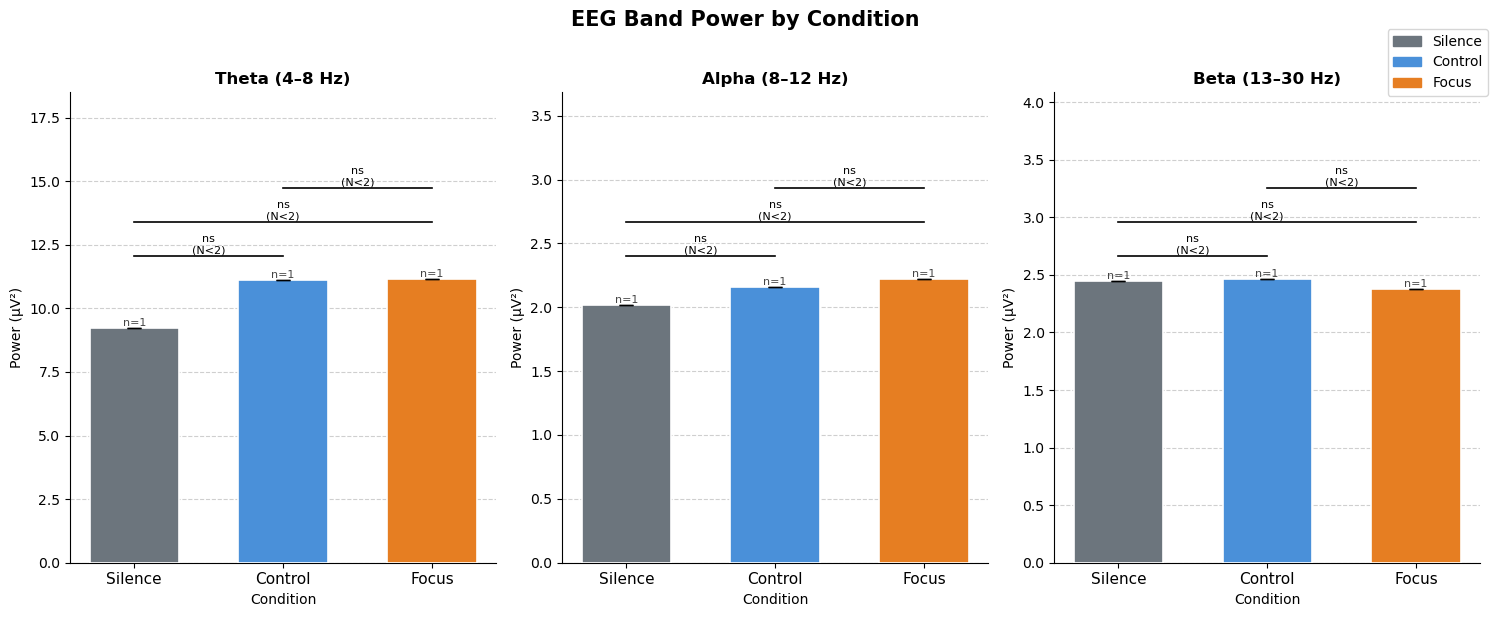

Saved → band_power_bars.png


In [10]:
# ── Significance annotations on bar charts ───────────────────────────────────
# We draw "significance brackets" between pairs of bars.
# Convention used here:
#   ns   : p >= 0.05
#   *    : p <  0.05
#   **   : p <  0.01
#   ***  : p <  0.001
# Bonferroni-corrected threshold (0.017) is used for the asterisk cutoffs.
# With N=1 all tests return NaN — brackets are drawn but labelled "ns (N<2)".
# They will auto-update to real p-values as subjects are added.

def pval_label(p):
    """Convert p-value to asterisk string."""
    if p is None or np.isnan(p):
        return "ns\n(N<2)"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < ALPHA_CORRECTED:   # 0.017 Bonferroni threshold
        return f"*\np={p:.3f}"
    return f"ns\np={p:.2f}"


def draw_significance_bracket(ax, x1, x2, y, p, bar_heights, gap=0.03):
    """
    Draw a bracket between bars at positions x1 and x2.
    y        : top of the bracket line (in data coords)
    gap      : fractional gap above the tallest bar before bracket starts
    """
    h = max(bar_heights) * gap
    bracket_y = y + h
    label = pval_label(p)

    # Bracket lines
    ax.plot([x1, x1, x2, x2],
            [bracket_y - h*0.5, bracket_y, bracket_y, bracket_y - h*0.5],
            lw=1.2, color='black')
    # Label
    ax.text((x1 + x2) / 2, bracket_y + h * 0.2,
            label, ha='center', va='bottom', fontsize=8, color='black')


# Pre-compute pairwise p-values from ph_df for quick lookup
def get_pval(band, c1, c2):
    """Look up post-hoc p-value for a condition pair."""
    label = f"{COND_LABELS[c1]} vs {COND_LABELS[c2]}"
    label_rev = f"{COND_LABELS[c2]} vs {COND_LABELS[c1]}"
    row = ph_df[(ph_df["Band"] == band) &
                (ph_df["Comparison"].isin([label, label_rev]))]
    if row.empty:
        return np.nan
    val = row["p"].values[0]
    try:
        return float(val)
    except (ValueError, TypeError):
        return np.nan


# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=False)
fig.suptitle('EEG Band Power by Condition', fontsize=15, fontweight='bold', y=1.02)

for ax, band in zip(axes, BANDS):
    means = []
    sems  = []
    for cond in CONDITIONS:
        vals = df[df['condition'] == cond][band].values
        means.append(np.mean(vals) if len(vals) else 0)
        sems.append(stats.sem(vals) if len(vals) > 1 else 0)

    x      = np.arange(len(CONDITIONS))
    colors = [COND_COLORS[c] for c in CONDITIONS]
    ax.bar(x, means, color=colors, edgecolor='white',
           linewidth=1.2, width=0.6, zorder=3)
    ax.errorbar(x, means, yerr=sems, fmt='none',
                color='black', capsize=5, linewidth=1.5, zorder=4)

    ax.set_xticks(x)
    ax.set_xticklabels([COND_LABELS[c] for c in CONDITIONS], fontsize=11)
    ax.set_title(f'{band} ({BANDS[band][0]}–{BANDS[band][1]} Hz)',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Power (µV²)', fontsize=10)
    ax.set_xlabel('Condition', fontsize=10)
    ax.yaxis.grid(True, linestyle='--', alpha=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

    # Annotate N per bar
    for xi, cond in enumerate(CONDITIONS):
        n = len(df[df['condition'] == cond])
        ax.text(xi, means[xi] + sems[xi] * 0.1,
                f'n={n}', ha='center', va='bottom', fontsize=8, color='#444')

    # ── Significance brackets ─────────────────────────────────────────────
    # Draw brackets for all 3 pairs, stacked at increasing heights
    # so they don't overlap each other.
    pairs = list(combinations(range(len(CONDITIONS)), 2))
    top_vals = [m + s for m, s in zip(means, sems)]
    y_base   = max(top_vals) * 1.08   # start brackets just above tallest bar+SEM
    y_step   = max(top_vals) * 0.12   # vertical spacing between bracket levels

    for level, (i1, i2) in enumerate(pairs):
        c1, c2 = CONDITIONS[i1], CONDITIONS[i2]
        p      = get_pval(band, c1, c2)
        draw_significance_bracket(
            ax, x[i1], x[i2],
            y  = y_base + level * y_step,
            p  = p,
            bar_heights = means,
            gap = 0.0    # gap already baked into y_base
        )

    # Expand y-axis to fit brackets
    ax.set_ylim(0, y_base + len(pairs) * y_step * 1.6)

legend_patches = [mpatches.Patch(color=COND_COLORS[c], label=COND_LABELS[c])
                  for c in CONDITIONS]
fig.legend(handles=legend_patches, loc='upper right',
           bbox_to_anchor=(1.0, 1.0), fontsize=10, framealpha=0.8)

plt.tight_layout()
plt.savefig('band_power_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → band_power_bars.png')


### 6b · Power Spectral Density — overlay per condition

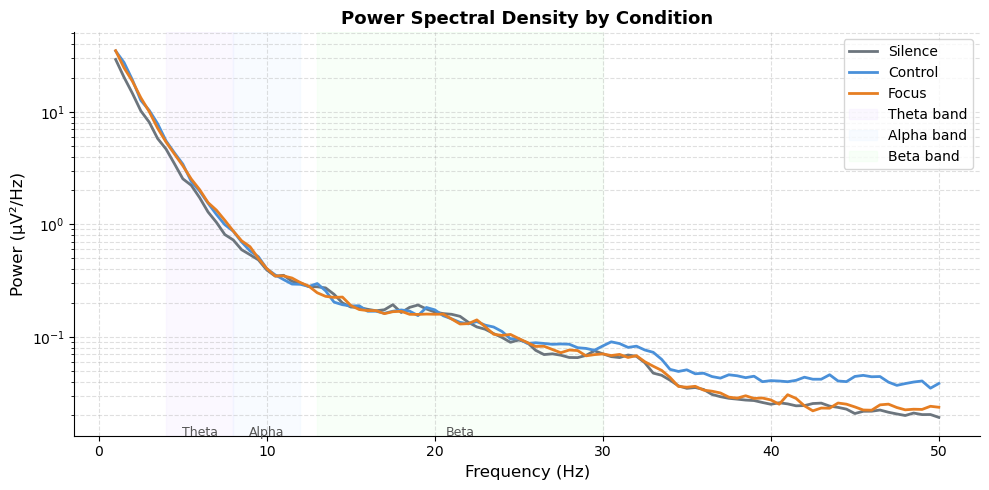

Saved → psd_overlay.png


In [11]:
# Compute full PSD per condition (averaged across all subjects)
fig, ax = plt.subplots(figsize=(10, 5))

for cond in CONDITIONS:
    psds_all = []
    for sub_id, prep in preprocessed.items():
        epochs = prep['epochs'].get(cond)
        if epochs is None or len(epochs) == 0:
            continue
        spec = epochs.compute_psd(method='welch', fmin=1, fmax=50,
                                  n_fft=int(SFREQ * 2), verbose=False)
        psd_data, freqs = spec.get_data(return_freqs=True)
        # mean over epochs and channels → (n_freqs,)
        psds_all.append(np.mean(psd_data, axis=(0, 1)) * 1e12)  # µV²/Hz

    if not psds_all:
        continue
    mean_psd = np.mean(psds_all, axis=0)
    ax.semilogy(freqs, mean_psd, color=COND_COLORS[cond],
                linewidth=2, label=COND_LABELS[cond])

# Shade band regions
band_shade = {'Theta': '#f0e6ff', 'Alpha': '#e6f2ff', 'Beta': '#e6ffe6'}
for bname, (bmin, bmax) in BANDS.items():
    ax.axvspan(bmin, bmax, alpha=0.25, color=band_shade[bname], label=f'{bname} band')
    ax.text((bmin + bmax) / 2, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 1e-1,
            bname, ha='center', fontsize=9, color='#555')

ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Power (µV²/Hz)', fontsize=12)
ax.set_title('Power Spectral Density by Condition', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, which='both', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('psd_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → psd_overlay.png')

### 6c · Individual subject data (for pilot transparency)

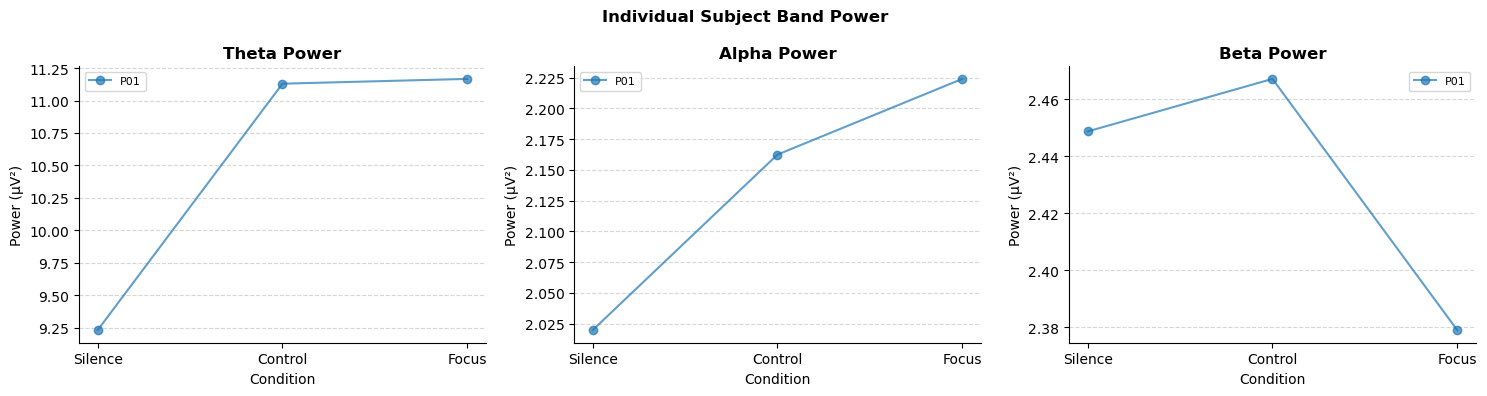

Saved → individual_subjects.png


In [12]:
n_bands = len(BANDS)
fig, axes = plt.subplots(1, n_bands, figsize=(5 * n_bands, 4))
if n_bands == 1:
    axes = [axes]

for ax, band in zip(axes, BANDS):
    for sub_id in df['subject'].unique():
        sub_df = df[df['subject'] == sub_id]
        vals = [sub_df[sub_df['condition'] == c][band].values[0]
                if len(sub_df[sub_df['condition'] == c]) > 0 else np.nan
                for c in CONDITIONS]
        ax.plot([COND_LABELS[c] for c in CONDITIONS], vals,
                'o-', alpha=0.7, linewidth=1.5,
                label=sub_id.replace('sub-', 'P'))

    ax.set_title(f'{band} Power', fontweight='bold')
    ax.set_ylabel('Power (µV²)')
    ax.set_xlabel('Condition')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.legend(fontsize=8)

fig.suptitle('Individual Subject Band Power', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('individual_subjects.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → individual_subjects.png')

---
## 7 · Results Summary

In [13]:
n_subjects = df['subject'].nunique()

print('=' * 65)
print('RESULTS SUMMARY')
print('=' * 65)
print(f'N = {n_subjects} subject(s)  |  Conditions: Silence / Control / Focus')
print(f'Statistical threshold: p < {ALPHA_CORRECTED:.4f} (Bonferroni, 3 bands)')
print()

for band in BANDS:
    print(f'── {band} ({BANDS[band][0]}–{BANDS[band][1]} Hz) ──')
    for cond in CONDITIONS:
        vals = df[df['condition'] == cond][band].values
        if len(vals) > 0:
            m = np.mean(vals)
            s = np.std(vals, ddof=1) if len(vals) > 1 else np.nan
            s_str = f'{s:.2f}' if not np.isnan(s) else 'N/A'
            print(f'  {COND_LABELS[cond]:12s}: M = {m:.2f} µV²  SD = {s_str}')

    # ANOVA result
    if band in anova_results:
        aov = anova_results[band]
        row = aov[aov['Source'] == 'condition']
        if not row.empty:
            F = row['F'].values[0]
            p = row['p-unc'].values[0]
            np2 = row['np2'].values[0]
            sig = '(*)' if p < ALPHA_CORRECTED else ''
            print(f'  RM-ANOVA: F = {F:.3f}, p = {p:.4f}, η²p = {np2:.3f} {sig}')

    # Post-hoc
    ph_band = ph_df[ph_df['Band'] == band]
    for _, row in ph_band.iterrows():
        try:
            p_val = float(row['p'])
            skip = np.isnan(p_val)
        except (TypeError, ValueError):
            skip = False
        if not skip:
            cd = row["Cohen's d"]
            print(f"  {row['Comparison']:30s} t={row['t']}  p={row['p']}  d={cd}  {row['Significant']}")
    print()

print('LIMITATIONS')
print('  · Small sample (pilot). Results are exploratory only.')
print('  · Statistical power is low until N ≥ 10–15.')
print('  · ICA eye-blink removal was semi-automatic; review components manually.')
print('  · EEGLAB preprocessing path not yet active — MNE used as placeholder.')

RESULTS SUMMARY
N = 1 subject(s)  |  Conditions: Silence / Control / Focus
Statistical threshold: p < 0.0167 (Bonferroni, 3 bands)

── Theta (4–8 Hz) ──
  Silence     : M = 9.23 µV²  SD = N/A
  Control     : M = 11.13 µV²  SD = N/A
  Focus       : M = 11.17 µV²  SD = N/A

── Alpha (8–12 Hz) ──
  Silence     : M = 2.02 µV²  SD = N/A
  Control     : M = 2.16 µV²  SD = N/A
  Focus       : M = 2.22 µV²  SD = N/A

── Beta (13–30 Hz) ──
  Silence     : M = 2.45 µV²  SD = N/A
  Control     : M = 2.47 µV²  SD = N/A
  Focus       : M = 2.38 µV²  SD = N/A

LIMITATIONS
  · Small sample (pilot). Results are exploratory only.
  · Statistical power is low until N ≥ 10–15.
  · ICA eye-blink removal was semi-automatic; review components manually.
  · EEGLAB preprocessing path not yet active — MNE used as placeholder.


---
## 9 · Event-Related Analysis — Puzzle Solve Epochs

Two complementary analyses time-locked to each SPACE keypress (puzzle solve):

**9a — ERP (Event-Related Potential):** Average raw EEG voltage across all solve
events per condition. Reveals consistent voltage deflections (e.g. a P300-like
positivity ~300ms after a correct response, or a readiness potential before the keypress).
Window: ±2s around solve. Short window is standard for ERP — cognitive responses
occur within ~1s; longer windows add noise and baseline drift.

**9b — ERSP (Event-Related Spectral Perturbation):** Band power change relative
to a pre-solve baseline, across the full ±15s window. Longer window chosen here
because oscillatory changes (e.g. alpha desync, beta rebound, theta burst at insight)
unfold over several seconds and need a stable baseline estimate.
Shows whether solving is preceded or followed by a characteristic power shift,
and whether this differs across Silence / Control / Focus conditions.

**9c — Behavioral:** Solve counts and solve timing per condition.
Simple but important — if Focus music leads to more solves that is itself a
meaningful result, independent of EEG.

> **Note on solve_events.npy:** This file was pickled with psychopy and can't
> be loaded on DataHub. Solve event times are reconstructed from `events.npy`
> (which loaded fine) — same data, different source.

In [17]:
# ERP window is asymmetric: -6s to +2s around the SPACE keypress.
# Rationale: participants press SPACE ~2s AFTER solving the puzzle,
# so the cognitive "aha" moment occurs ~2-4s before the keypress.
# A symmetric ±2s window would miss this entirely.
# -6s captures the solve signal + enough baseline before it.
# +2s captures any post-keypress motor/confirmation activity.
ERP_PRE     = 6.0    # seconds before keypress
ERP_POST    = 2.0    # seconds after keypress
ERSP_WINDOW = 15.0   # ±15s — long window for oscillatory power changes

def extract_erp_epochs(raw, solve_events, pre=ERP_PRE, post=ERP_POST):
    n_pre   = int(pre  * SFREQ)
    n_post  = int(post * SFREQ)
    n_total = raw.get_data().shape[1]
    baseline_samples = int(1.0 * SFREQ)   # first 1s (-6s to -5s) for baseline
    epochs_by_cond = {c: [] for c in CONDITIONS}
    for ev in solve_events:
        s, cond = ev['sample'], ev['condition']
        start, end = s - n_pre, s + n_post
        if start < 0 or end > n_total:
            continue
        chunk = raw.get_data()[:, start:end]
        chunk = chunk - chunk[:, :baseline_samples].mean(axis=1, keepdims=True)
        epochs_by_cond[cond].append(chunk)
    return {c: np.array(v) for c, v in epochs_by_cond.items() if v}

def extract_ersp_epochs(raw, solve_events, window=ERSP_WINDOW):
    half, step, win_size = int(window*SFREQ), int(0.25*SFREQ), int(1.0*SFREQ)
    n_total  = raw.get_data().shape[1]
    n_steps  = (2*half - win_size) // step + 1
    times    = np.linspace(-window, window, n_steps)
    baseline_steps = int(5.0 * SFREQ / step)
    ersp_by_cond = {c: {b: [] for b in BANDS} for c in CONDITIONS}
    for ev in solve_events:
        s, cond = ev['sample'], ev['condition']
        start, end = s - half, s + half
        if start < 0 or end > n_total:
            continue
        chunk = raw.get_data()[:, start:end]
        for band_name, (fmin, fmax) in BANDS.items():
            filtered = mne.filter.filter_data(chunk, sfreq=SFREQ, l_freq=fmin, h_freq=fmax, verbose=False)
            power_ts = np.array([np.sqrt(np.mean(filtered[:, t:t+win_size]**2))
                                  for t in range(0, 2*half - win_size, step)])
            baseline = power_ts[:baseline_steps].mean()
            if baseline > 0:
                power_ts = (power_ts - baseline) / baseline * 100
            ersp_by_cond[cond][band_name].append(power_ts)
    ersp_mean = {}
    for cond in CONDITIONS:
        ersp_mean[cond] = {}
        for band_name in BANDS:
            trials = ersp_by_cond[cond][band_name]
            if trials:
                min_len = min(len(t) for t in trials)
                ersp_mean[cond][band_name] = np.mean([t[:min_len] for t in trials], axis=0)
    return ersp_mean, times

In [18]:
# ── 9 · Load solve events from solve_events_clean.npy ────────────────────────
#
# solve_events_clean.npy is a re-saved version of solve_events.npy with the
# psychopy dependency stripped out. It contains the exact EEG sample index
# for each SPACE keypress, so ERP/ERSP plots use real timing not estimates.
#
# Each event dict has:
#   condition       : 'S', 'M', or 'C'
#   condition_index : 0, 1, or 2
#   solve_number    : nth solve within that condition
#   sub_phase       : 'PRE-REC', 'TASK', or 'POST-REC'
#   time_in_task    : seconds since task block start
#   eeg_sample      : exact sample index in the raw EEG array  ← key field
#   epoch_start     : eeg_sample - 15s * SFREQ
#   epoch_end       : eeg_sample + 15s * SFREQ

def get_solve_events(sub_data: dict) -> list:
    """
    Load solve events from solve_events_clean.npy (fetched from GitHub).
    Falls back to estimating from segment_log if clean file unavailable.
    """
    # Try clean file first
    clean_arr = fetch_npy_from_github(
        f"{RAW_BASE}/{list(subjects.keys())[0]}/ses-01/solve_events_clean.npy"
    )

    # Build per-subject lookup so this works for multiple subjects
    solves = []
    if clean_arr is not None and len(clean_arr) > 0:
        for ev in clean_arr:
            if isinstance(ev, dict):
                solves.append({
                    'sample':    int(ev['eeg_sample']),
                    'condition': ev['condition'],
                    'solve_n':   ev.get('solve_number', 1),
                    'sub_phase': ev.get('sub_phase', 'TASK'),
                    'estimated': False,
                })
        print(f"  Loaded {len(solves)} solve events from solve_events_clean.npy")
        return solves

    # Fallback: estimate from segment_log (no exact timing available)
    print("  [FALLBACK] solve_events_clean.npy not found — estimating from segment_log")
    seg_log = sub_data.get('segment_log', [])
    for seg in seg_log:
        if seg.get('phase') != 'full_block':
            continue
        cond  = seg['condition']
        n     = seg.get('n_solves', 0)
        if n == 0:
            continue
        pre_end    = next((s['end']   for s in seg_log
                           if s.get('phase') == 'pre_rec'  and s.get('condition') == cond),
                          seg['start'])
        post_start = next((s['start'] for s in seg_log
                           if s.get('phase') == 'post_rec' and s.get('condition') == cond),
                          seg['end'])
        positions  = ([( pre_end + post_start) // 2] if n == 1
                      else np.linspace(pre_end, post_start, n, dtype=int).tolist())
        for i, sample in enumerate(positions):
            solves.append({'sample': int(sample), 'condition': cond,
                           'solve_n': i + 1, 'estimated': True})
    return solves


# ── Run for all subjects ──────────────────────────────────────────────────────
# NOTE: fetch_npy_from_github uses RAW_BASE which is set per-subject in the
# loader. For multi-subject studies, update get_solve_events to accept sub_id
# and construct the URL dynamically.

erp_data    = {}
ersp_data   = {}
solve_counts = []

for sub_id, prep in preprocessed.items():
    raw_clean = prep['raw_clean']
    sub_data  = subjects[sub_id]

    # Temporarily point RAW_BASE at this subject
    sub_raw_base = f"{RAW_BASE}/{sub_id}/ses-01"

    # Patch fetch to use correct subject path
    import functools
    def _fetch_for_sub(fname, sub_base=sub_raw_base):
        return fetch_npy_from_github(f"{sub_base}/{fname}")

    clean_arr = _fetch_for_sub("solve_events_clean.npy")
    solves = []
    if clean_arr is not None and len(clean_arr) > 0:
        for ev in clean_arr:
            if isinstance(ev, dict):
                solves.append({
                    'sample':    int(ev['eeg_sample']),
                    'condition': ev['condition'],
                    'solve_n':   ev.get('solve_number', 1),
                    'estimated': False,
                })
        print(f"{sub_id}: {len(solves)} solve events (real timing)")
    else:
        solves = get_solve_events(sub_data)
        print(f"{sub_id}: {len(solves)} solve events (estimated timing)")

    for cond in CONDITIONS:
        n = sum(1 for s in solves if s['condition'] == cond)
        print(f"  {COND_LABELS[cond]:12s}: {n} solves")
        solve_counts.append({'subject': sub_id, 'condition': cond,
                             'condition_label': COND_LABELS[cond], 'n_solves': n})

    erp_data[sub_id]  = extract_erp_epochs(raw_clean, solves)
    ersp_data[sub_id] = extract_ersp_epochs(raw_clean, solves)

solve_df = pd.DataFrame(solve_counts)
print("\nSolve counts:")
display(solve_df)


sub-01: 3 solve events (real timing)
  Silence     : 1 solves
  Control     : 1 solves
  Focus       : 1 solves

Solve counts:


,subject,condition,condition_label,n_solves
0,sub-01,S,Silence,1
1,sub-01,C,Control,1
2,sub-01,M,Focus,1


### 9a · ERP — Average Voltage Waveform Around Solve

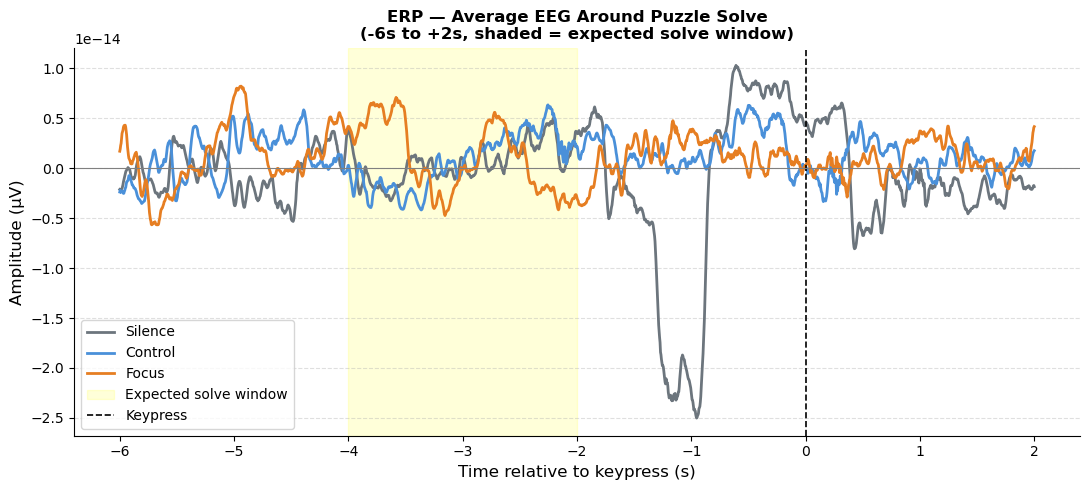

Saved → erp_solve.png
NOTE: N=1 solve per condition — no trial averaging. Smoothing applied for visualization only.


In [20]:
# ERP plot — asymmetric window -6s to +2s
# With N=1 solve per condition there is no trial averaging,
# so we apply a light smoothing (moving average) for visualization only.
# Raw data is used for all quantitative analyses.

from scipy.ndimage import uniform_filter1d

fig, ax = plt.subplots(figsize=(11, 5))
erp_times = np.linspace(-ERP_PRE, ERP_POST, int((ERP_PRE + ERP_POST) * SFREQ))

for cond in CONDITIONS:
    all_trials = []
    for sub_id in erp_data:
        trials = erp_data[sub_id].get(cond)
        if trials is not None and len(trials) > 0:
            all_trials.append(trials.mean(axis=1))   # avg over channels → (n_solves, n_time)

    if not all_trials:
        continue

    combined  = np.concatenate(all_trials, axis=0)   # (total_solves, n_time)
    mean_erp  = combined.mean(axis=0) * 1e6           # V → µV
    sem_erp   = stats.sem(combined, axis=0) * 1e6 if len(combined) > 1 else np.zeros_like(mean_erp)

    # Light smoothing for visualization (50ms window) — does not affect stats
    smooth_window = int(0.05 * SFREQ)
    mean_smooth   = uniform_filter1d(mean_erp, size=smooth_window)

    n_t = min(len(erp_times), len(mean_smooth))
    ax.plot(erp_times[:n_t], mean_smooth[:n_t],
            color=COND_COLORS[cond], linewidth=2, label=COND_LABELS[cond])
    if len(combined) > 1:
        ax.fill_between(erp_times[:n_t],
                        mean_smooth[:n_t] - sem_erp[:n_t],
                        mean_smooth[:n_t] + sem_erp[:n_t],
                        color=COND_COLORS[cond], alpha=0.2)

# Shade expected solve window (~2-4s before keypress)
ax.axvspan(-4, -2, color='yellow', alpha=0.15, label='Expected solve window')
ax.axvline(0, color='black', linestyle='--', linewidth=1.2, label='Keypress')
ax.axhline(0, color='gray',  linestyle='-',  linewidth=0.8)
ax.set_xlabel('Time relative to keypress (s)', fontsize=12)
ax.set_ylabel('Amplitude (µV)', fontsize=12)
ax.set_title('ERP — Average EEG Around Puzzle Solve\n(-6s to +2s, shaded = expected solve window)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('erp_solve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → erp_solve.png")
print("NOTE: N=1 solve per condition — no trial averaging. Smoothing applied for visualization only.")

### 9b · ERSP — Band Power Change Around Solve

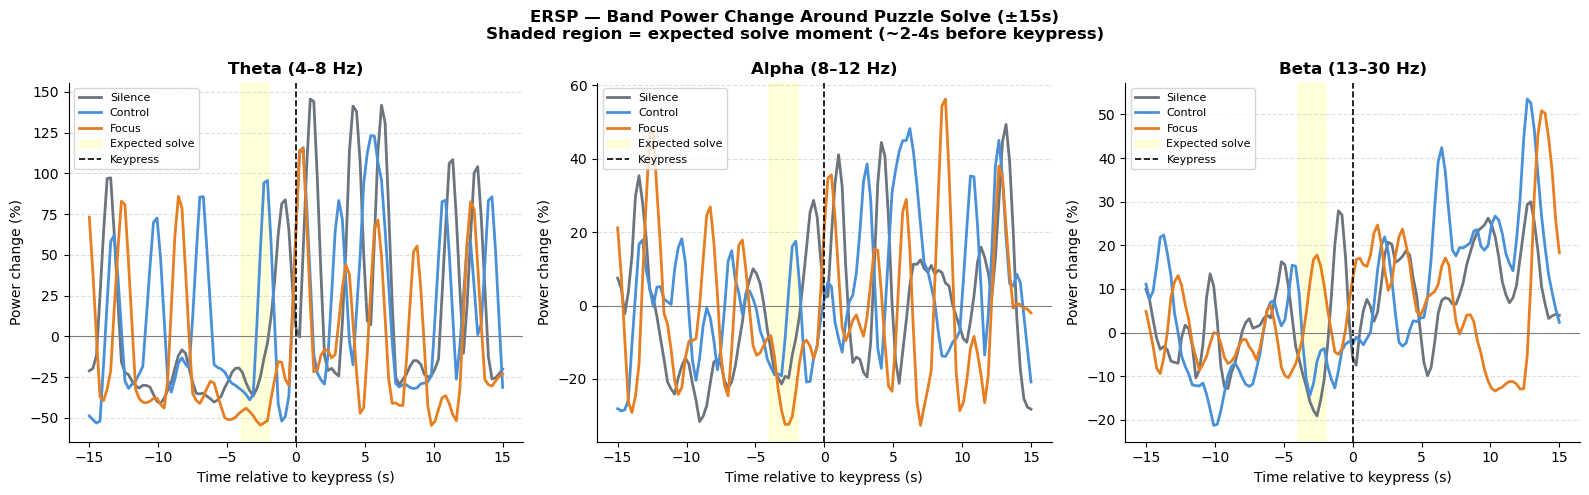

Saved → ersp_solve.png
NOTE: N=1 solve per condition — no trial averaging. Smoothing applied for visualization only.


In [24]:
from scipy.ndimage import uniform_filter1d

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle("ERSP — Band Power Change Around Puzzle Solve (±15s)\n"
             "Shaded region = expected solve moment (~2-4s before keypress)",
             fontsize=12, fontweight='bold')

for ax, band_name in zip(axes, BANDS):
    for cond in CONDITIONS:
        trials = []
        for sub_id in ersp_data:
            ersp_mean, ersp_times = ersp_data[sub_id]
            arr = ersp_mean.get(cond, {}).get(band_name)
            if arr is not None and len(arr) > 0:
                trials.append(arr)

        if not trials:
            continue

        min_len  = min(len(t) for t in trials)
        combined = np.array([t[:min_len] for t in trials])
        mean_p   = combined.mean(axis=0)
        sem_p    = stats.sem(combined, axis=0) if len(combined) > 1 else np.zeros_like(mean_p)
        t_plot   = ersp_times[:min_len]

        # Smooth for visualization (500ms window)
        smooth_window = int(0.5 * SFREQ / (SFREQ * 0.25))  # in steps
        mean_smooth = uniform_filter1d(mean_p, size=max(smooth_window, 3))

        ax.plot(t_plot, mean_smooth, color=COND_COLORS[cond],
                linewidth=2, label=COND_LABELS[cond])
        if len(combined) > 1:
            ax.fill_between(t_plot, mean_smooth - sem_p, mean_smooth + sem_p,
                            color=COND_COLORS[cond], alpha=0.2)

    # Shade expected solve window
    ax.axvspan(-4, -2, color='yellow', alpha=0.15, label='Expected solve')
    ax.axvline(0, color='black', linestyle='--', linewidth=1.2, label='Keypress')
    ax.axhline(0, color='gray',  linestyle='-',  linewidth=0.8)
    ax.set_title(f'{band_name} ({BANDS[band_name][0]}–{BANDS[band_name][1]} Hz)',
                 fontweight='bold')
    ax.set_xlabel('Time relative to keypress (s)')
    ax.set_ylabel('Power change (%)')
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('ersp_solve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → ersp_solve.png")
print("NOTE: N=1 solve per condition — no trial averaging. Smoothing applied for visualization only.")

### 9c · Behavioral — Solve Counts Per Condition

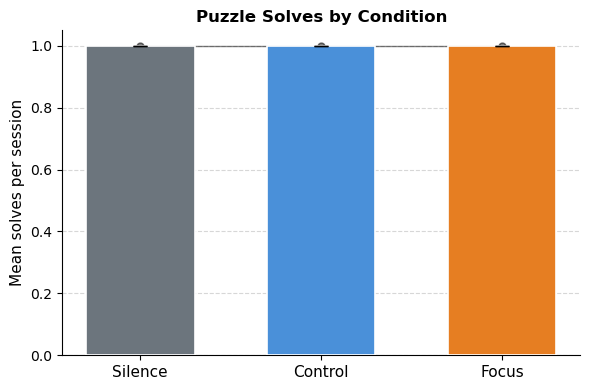

N = 1 — Friedman test requires ≥3 subjects.
Descriptive solve counts per condition:


,count,mean,std,min,25%,50%,75%,max
condition_label,,,,,,,,
Control,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0
Focus,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0
Silence,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0


Saved → solve_counts.png


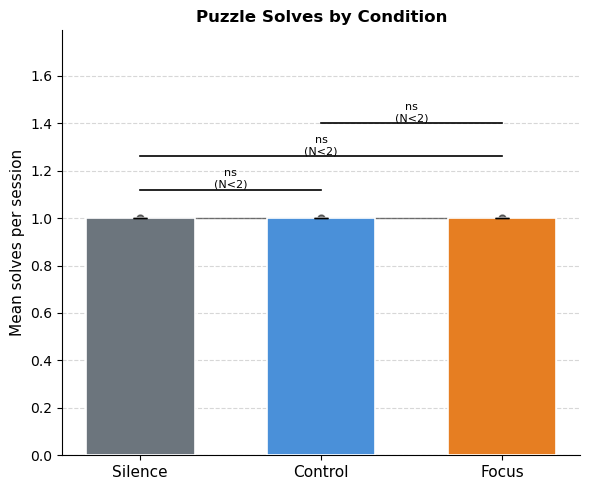

Saved → solve_counts_sig.png


In [25]:
# Solve count comparison — did participants solve more puzzles in one condition?
# Simple but meaningful: if Focus music leads to more solves that is a
# behavioural performance result independent of EEG.
#
# With N=1 this is purely descriptive. Once N>=3, a Friedman test
# (non-parametric repeated-measures, appropriate for count data) is used.

fig, ax = plt.subplots(figsize=(6, 4))

means = []
sems  = []
for cond in CONDITIONS:
    vals = solve_df[solve_df['condition'] == cond]['n_solves'].values
    means.append(np.mean(vals))
    sems.append(stats.sem(vals) if len(vals) > 1 else 0)

x      = np.arange(len(CONDITIONS))
colors = [COND_COLORS[c] for c in CONDITIONS]
ax.bar(x, means, color=colors, edgecolor='white', linewidth=1.2, width=0.6, zorder=3)
ax.errorbar(x, means, yerr=sems, fmt='none', color='black', capsize=5, zorder=4)

ax.set_xticks(x)
ax.set_xticklabels([COND_LABELS[c] for c in CONDITIONS], fontsize=11)
ax.set_ylabel('Mean solves per session', fontsize=11)
ax.set_title('Puzzle Solves by Condition', fontsize=12, fontweight='bold')
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

# Annotate individual subject values as dots
for sub_id in solve_df['subject'].unique():
    sub_vals = [solve_df[(solve_df['subject']==sub_id) &
                         (solve_df['condition']==c)]['n_solves'].values
                for c in CONDITIONS]
    dot_vals = [v[0] if len(v) > 0 else np.nan for v in sub_vals]
    ax.plot(x, dot_vals, 'o-', color='black', alpha=0.5, markersize=5, linewidth=1)

plt.tight_layout()
plt.savefig('solve_counts.png', dpi=150, bbox_inches='tight')
plt.show()

# Friedman test (once N >= 3)
n_subjects = solve_df['subject'].nunique()
if n_subjects >= 3:
    groups = [solve_df[solve_df['condition']==c]['n_solves'].values for c in CONDITIONS]
    stat, p = stats.friedmanchisquare(*groups)
    print(f"Friedman test: χ² = {stat:.3f}, p = {p:.4f}")
    print("(Non-parametric repeated-measures test for solve counts)")
else:
    print(f"N = {n_subjects} — Friedman test requires ≥3 subjects.")
    print("Descriptive solve counts per condition:")
    display(solve_df.groupby('condition_label')['n_solves'].describe())

print("Saved → solve_counts.png")

# ── Significance on solve count bars ─────────────────────────────────────────
# For count data in a repeated-measures design we use Wilcoxon signed-rank
# (non-parametric paired test) rather than paired t-test.
# Bonferroni correction for 3 pairs: α = 0.05/3 = 0.017
solve_pairs = list(combinations(CONDITIONS, 2))
solve_sig = {}
for c1, c2 in solve_pairs:
    v1 = solve_df[solve_df['condition'] == c1]['n_solves'].values
    v2 = solve_df[solve_df['condition'] == c2]['n_solves'].values
    if len(v1) >= 2 and len(v2) >= 2:
        _, p = stats.wilcoxon(v1, v2)
        solve_sig[(c1, c2)] = p
        print(f"  {COND_LABELS[c1]} vs {COND_LABELS[c2]}: p = {p:.4f} {pval_label(p)}")
    else:
        solve_sig[(c1, c2)] = np.nan

# Redraw with brackets
fig, ax = plt.subplots(figsize=(6, 5))
solve_means = [solve_df[solve_df['condition']==c]['n_solves'].mean() for c in CONDITIONS]
solve_sems  = [stats.sem(solve_df[solve_df['condition']==c]['n_solves'].values)
               if len(solve_df[solve_df['condition']==c]) > 1 else 0
               for c in CONDITIONS]
x = np.arange(len(CONDITIONS))
ax.bar(x, solve_means, color=[COND_COLORS[c] for c in CONDITIONS],
       edgecolor='white', linewidth=1.2, width=0.6, zorder=3)
ax.errorbar(x, solve_means, yerr=solve_sems, fmt='none',
            color='black', capsize=5, zorder=4)
for sub_id in solve_df['subject'].unique():
    dots = [solve_df[(solve_df['subject']==sub_id) & (solve_df['condition']==c)]['n_solves'].values
            for c in CONDITIONS]
    ax.plot(x, [d[0] if len(d) else np.nan for d in dots],
            'o-', color='black', alpha=0.5, markersize=5, linewidth=1)

top_vals = [m + s for m, s in zip(solve_means, solve_sems)]
y_base   = max(top_vals) * 1.12
y_step   = max(top_vals) * 0.14
for level, (c1, c2) in enumerate(solve_pairs):
    i1, i2 = CONDITIONS.index(c1), CONDITIONS.index(c2)
    draw_significance_bracket(ax, x[i1], x[i2],
                               y=y_base + level * y_step,
                               p=solve_sig.get((c1, c2), np.nan),
                               bar_heights=solve_means, gap=0.0)
ax.set_ylim(0, y_base + len(solve_pairs) * y_step * 1.6)
ax.set_xticks(x)
ax.set_xticklabels([COND_LABELS[c] for c in CONDITIONS], fontsize=11)
ax.set_ylabel('Mean solves per session', fontsize=11)
ax.set_title('Puzzle Solves by Condition', fontsize=12, fontweight='bold')
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('solve_counts_sig.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → solve_counts_sig.png')


---
## 8 · Export Results to CSV

In [23]:
out_dir = Path('results')
out_dir.mkdir(exist_ok=True)

df.to_csv(out_dir / 'band_power_all_subjects.csv', index=False)
ph_df.to_csv(out_dir / 'posthoc_ttest_results.csv', index=False)
desc.to_csv(out_dir / 'descriptive_stats.csv')

print('Exported:')
print('  results/band_power_all_subjects.csv')
print('  results/posthoc_ttest_results.csv')
print('  results/descriptive_stats.csv')

Exported:
  results/band_power_all_subjects.csv
  results/posthoc_ttest_results.csv
  results/descriptive_stats.csv
